# Cinsiyet Sınıflandırması

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

In [2]:
df = pd.read_csv('gender_classification_v7.csv')

In [3]:
df

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [4]:
# 2. Hedef değişkeni (Gender) sayısala çevirme: Male -> 1, Female -> 0
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [5]:
# 3. Özellikleri (X) ve Hedef Değişkeni (y) belirleme
# Sütunlar: long_hair, forehead_width_cm, forehead_height_cm, nose_wide, nose_long, lips_thin, distance_nose_to_lip_long
x = df.drop(columns=['gender'])
y = df['gender']

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)


In [7]:
model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
y_pred = model.predict(x_test)
print(f"Model Doğruluk Skoru (Accuracy): {accuracy_score(y_test, y_pred):.4f}")

Model Doğruluk Skoru (Accuracy): 0.9590


In [9]:
# 7. Modeli Streamlit uygulaması için kaydetme
joblib.dump(model, "gender_classifier_model.pkl")
print("Model başarıyla 'gender_classifier_model.pkl' olarak kaydedildi!")

Model başarıyla 'gender_classifier_model.pkl' olarak kaydedildi!


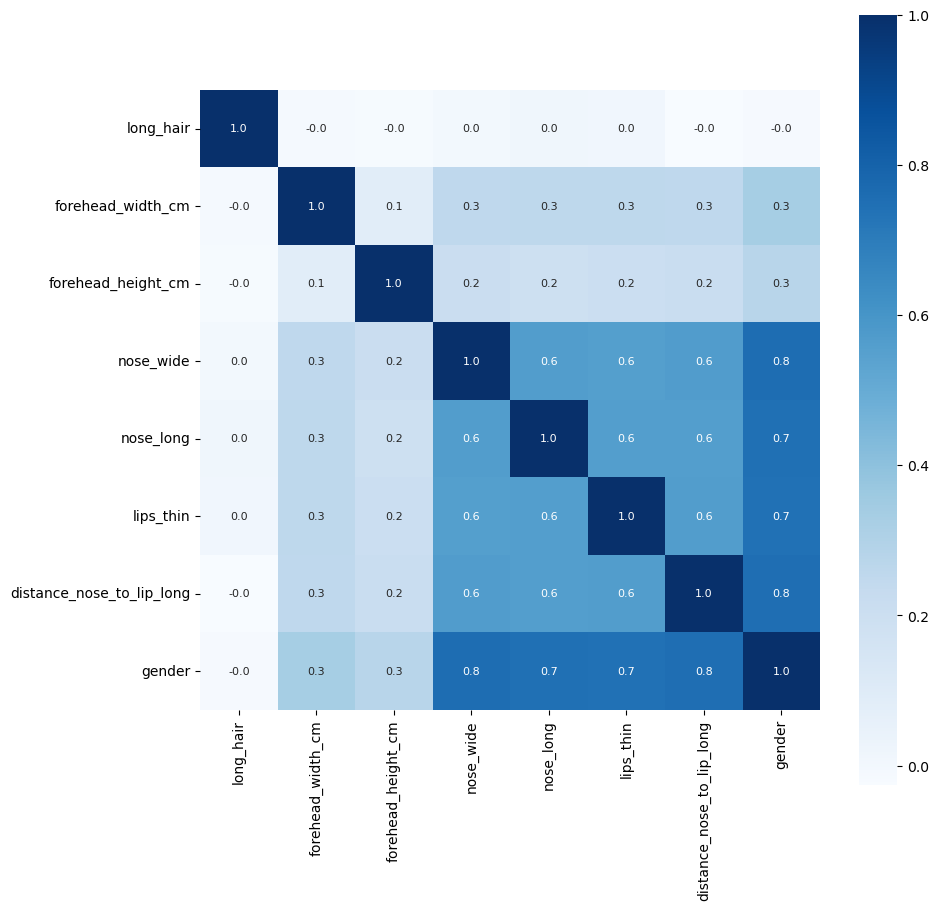

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation = df.corr()

plt.figure(figsize=(10, 10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')
plt.show()
